### `Dataset` - https://drive.google.com/file/d/1I1zbJMkjwOitG3IjX40SvC79YYvoULzy/view?usp=drive_link

### Importing Libraries

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load The `Dataset`

In [130]:
df = pd.read_csv("/content/Task1_ecommerce_dataset.csv")
df.head()

,order_id,customer_id,order_date,category,product_price,quantity,discount_pct,shipping_cost,country,payment_method,customer_age,is_member,return_flag,rating,delivery_days,revenue
0,ORD100000,CUST8270,2023-10-17,Books,6.66,8,0,5.59,France,Crypto,69.0,1,0,1.0,9.0,53.28
1,ORD100001,CUST8603,2022-04-25,Food,11.56,1,5,8.88,USA,Crypto,18.0,1,0,5.0,10.0,10.98
2,ORD100002,CUST1860,2022-01-26,Electronics,123.48,1,0,15.15,UK,PayPal,NaN,0,0,2.0,3.0,123.48
3,ORD100003,CUST6390,2022-10-09,Electronics,75.62,1,30,6.19,Australia,Credit Card,25.0,1,0,4.0,12.0,52.93
4,ORD100004,CUST6226,2022-09-08,Toys,17.04,5,15,4.96,Mexico,Crypto,39.0,1,0,4.0,1.0,72.42


In [131]:
df.shape

(15200, 16)

- Dataset has 15200 Rows and 16 Columns

In [132]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'product_price',
       'quantity', 'discount_pct', 'shipping_cost', 'country',
       'payment_method', 'customer_age', 'is_member', 'return_flag', 'rating',
       'delivery_days', 'revenue'],
      dtype='object')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15200 entries, 0 to 15199
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        15200 non-null  object 
 1   customer_id     15200 non-null  object 
 2   order_date      15200 non-null  object 
 3   category        15200 non-null  object 
 4   product_price   15200 non-null  float64
 5   quantity        15200 non-null  int64  
 6   discount_pct    15200 non-null  int64  
 7   shipping_cost   15200 non-null  float64
 8   country         15200 non-null  object 
 9   payment_method  15200 non-null  object 
 10  customer_age    14894 non-null  float64
 11  is_member       15200 non-null  int64  
 12  return_flag     15200 non-null  int64  
 13  rating          14743 non-null  float64
 14  delivery_days   15047 non-null  float64
 15  revenue         15200 non-null  float64
dtypes: float64(6), int64(4), object(6)
memory usage: 1.9+ MB


In [134]:
df.describe()

,product_price,quantity,discount_pct,shipping_cost,customer_age,is_member,return_flag,rating,delivery_days,revenue
count,15200.000000,15200.000000,15200.000000,15200.000000,14894.000000,15200.000000,15200.000000,14743.000000,15047.000000,15200.000000
mean,69.761522,4.989079,8.642763,8.196293,45.891164,0.651184,0.120789,3.886929,7.469728,304.864480
std,148.289744,2.582110,9.354628,4.600603,16.461714,0.476611,0.325893,1.130374,4.035681,627.748091
min,0.160000,1.000000,0.000000,0.010000,18.000000,0.000000,0.000000,1.000000,1.000000,0.700000
25%,14.390000,3.000000,0.000000,4.690000,32.000000,0.000000,0.000000,3.000000,4.000000,48.325000
50%,33.020000,5.000000,5.000000,7.960000,46.000000,1.000000,0.000000,4.000000,7.000000,127.150000
75%,75.085000,7.000000,15.000000,11.350000,60.000000,1.000000,0.000000,5.000000,11.000000,318.992500
max,6951.150000,9.000000,30.000000,26.400000,74.000000,1.000000,1.000000,5.000000,14.000000,21361.150000


- Dataset has ~15K rows and multiple features
- Mix of numeric + categorical variables

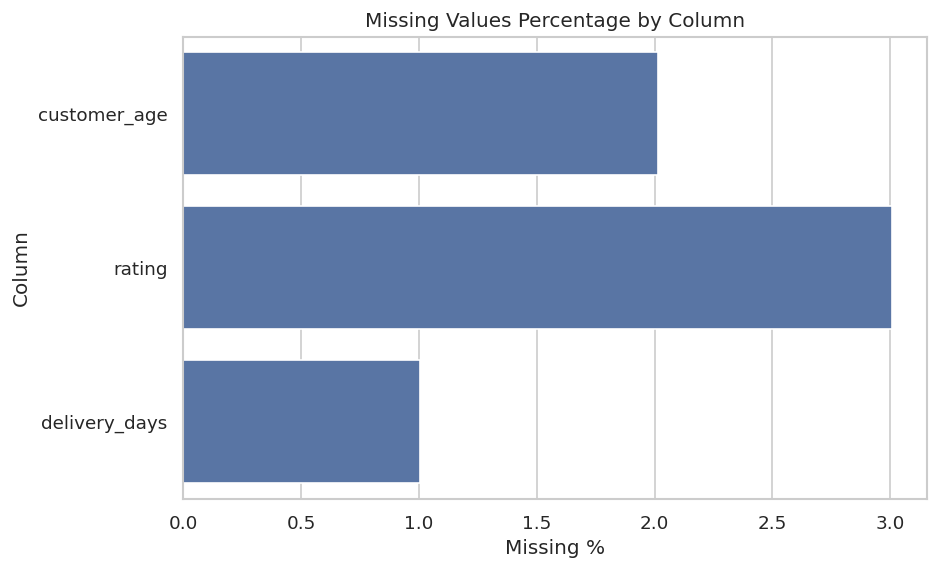

In [135]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent_df = missing_percent.reset_index()
missing_percent_df.columns = ['Column', 'Missing %']

# Filter
missing_percent_df = missing_percent_df[missing_percent_df['Missing %'] > 0]

# horizontal bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Missing %', y='Column', data=missing_percent_df, orient='h')

plt.title("Missing Values Percentage by Column")

plt.show()

Total Duplicate Rows: 200


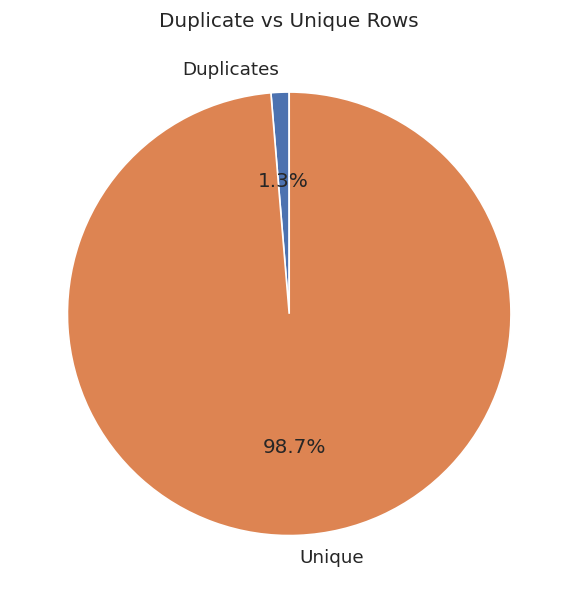

In [136]:
duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)
# Create small dataframe for visualization
dup_data = pd.DataFrame({
    'Type': ['Duplicates', 'Unique'],
    'Count': [duplicate_count, len(df) - duplicate_count]
})

# Plot Pie chart
plt.figure(figsize=(6, 6))
plt.pie(dup_data['Count'], labels=dup_data['Type'], autopct='%1.1f%%', startangle=90)
plt.title('Duplicate vs Unique Rows')
plt.show()

### `Data Cleaning : -`

- Missing Values -

In [137]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
category,0
product_price,0
quantity,0
discount_pct,0
shipping_cost,0
country,0
payment_method,0


In [138]:
df['rating'].fillna(df['rating'].mean(), inplace=True)
df['customer_age'].fillna(df['customer_age'].median(), inplace=True)
df['delivery_days'].fillna(df['delivery_days'].median(), inplace=True)

/tmp/ipykernel_2294/1519746670.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mean(), inplace=True)
/tmp/ipykernel_2294/1519746670.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [139]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
category,0
product_price,0
quantity,0
discount_pct,0
shipping_cost,0
country,0
payment_method,0


- Duplicates -

In [140]:
df.duplicated().sum()

np.int64(200)

In [141]:
df.drop_duplicates(inplace=True)

- Outliers -

<Axes: ylabel='product_price'>

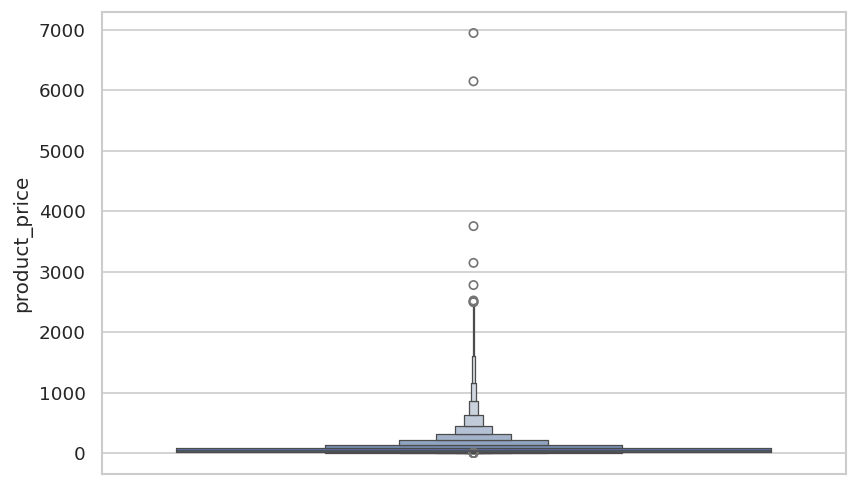

In [142]:
sns.boxenplot(df['product_price'])

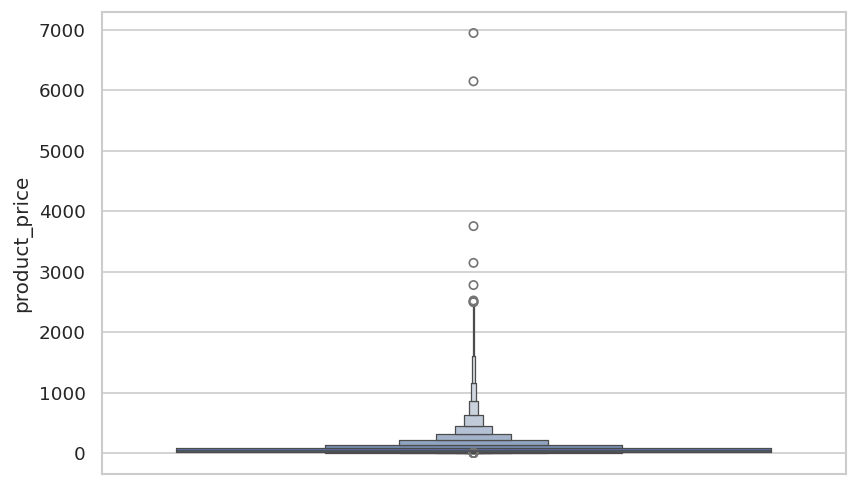

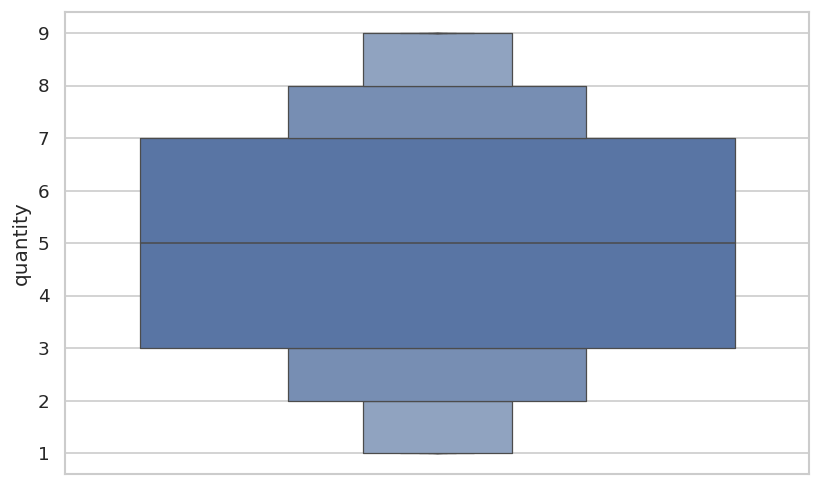

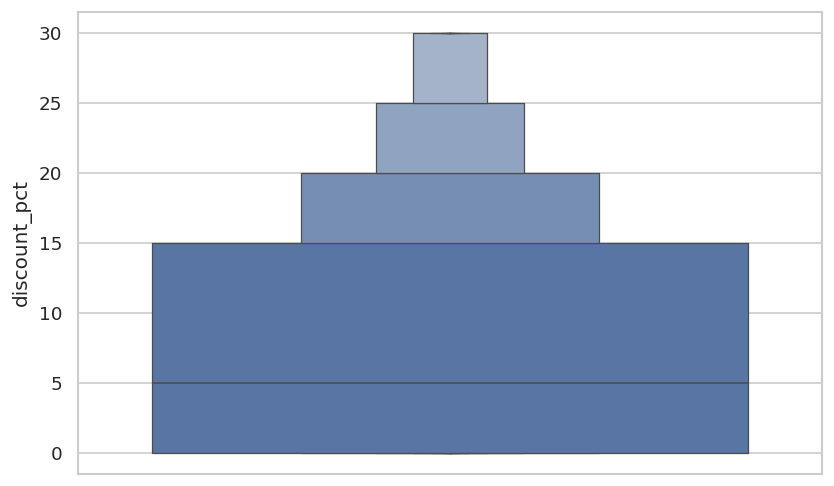

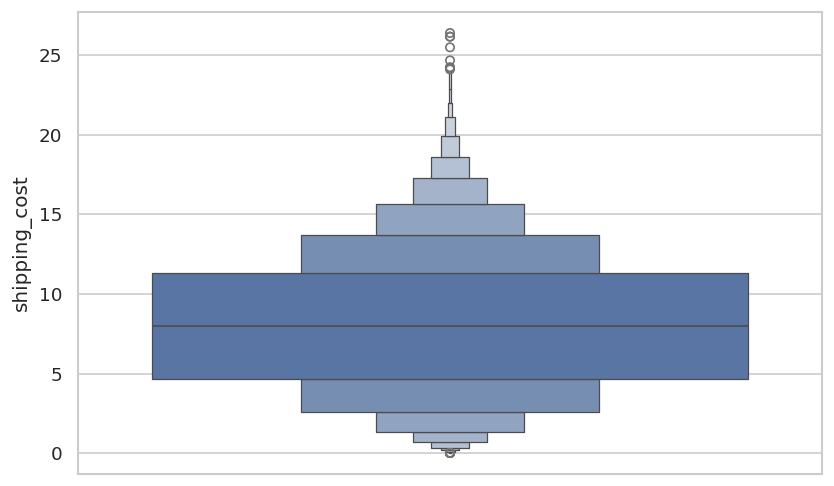

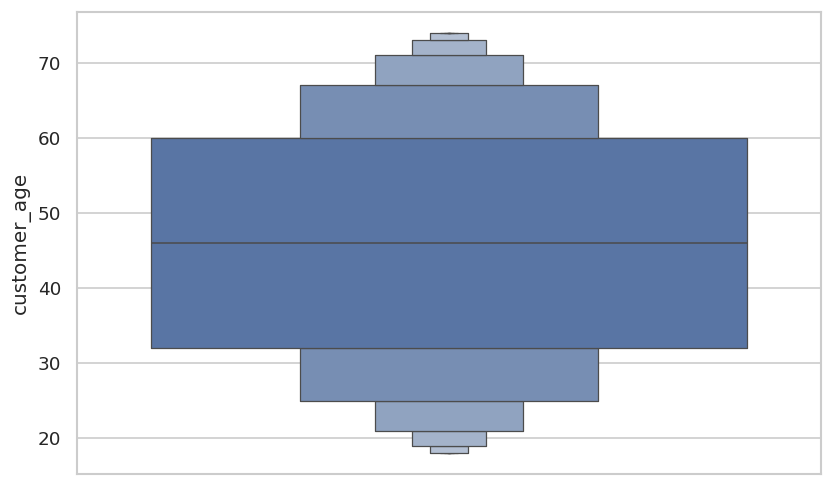

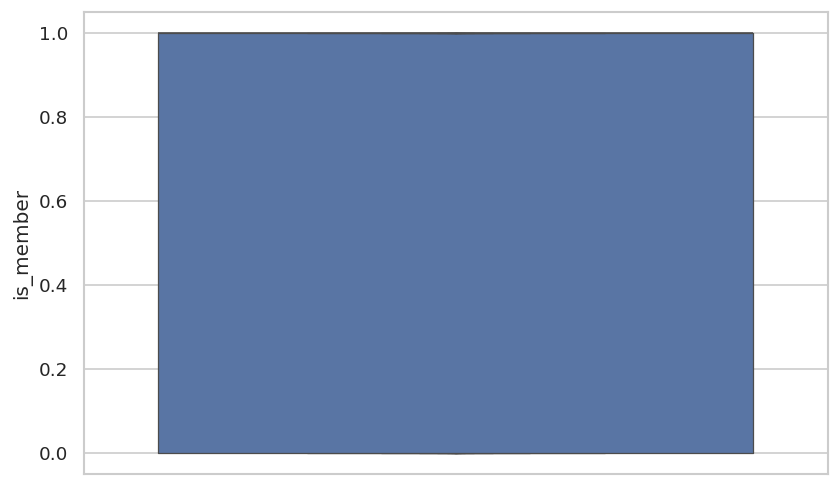

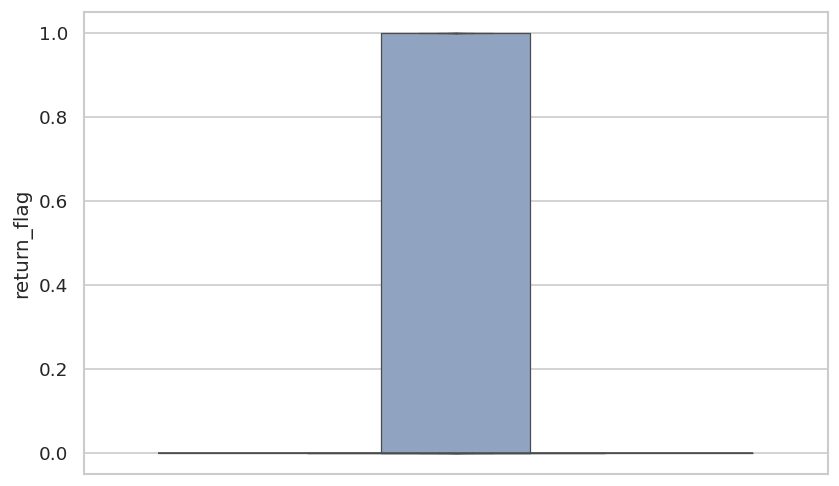

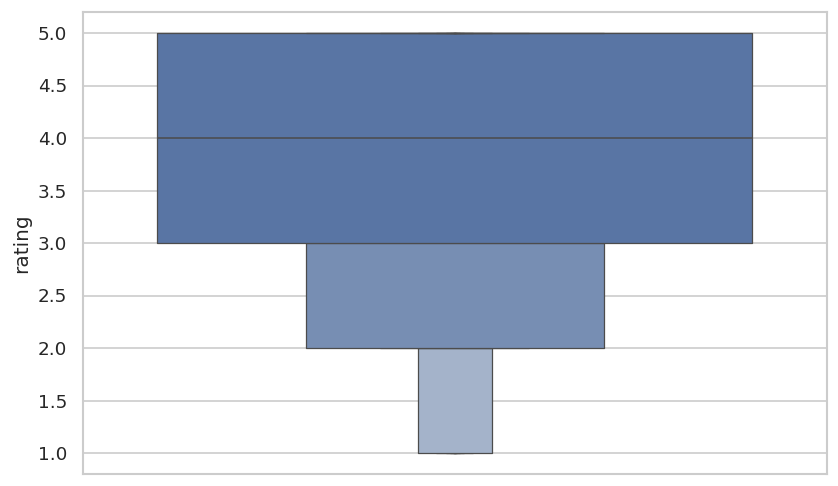

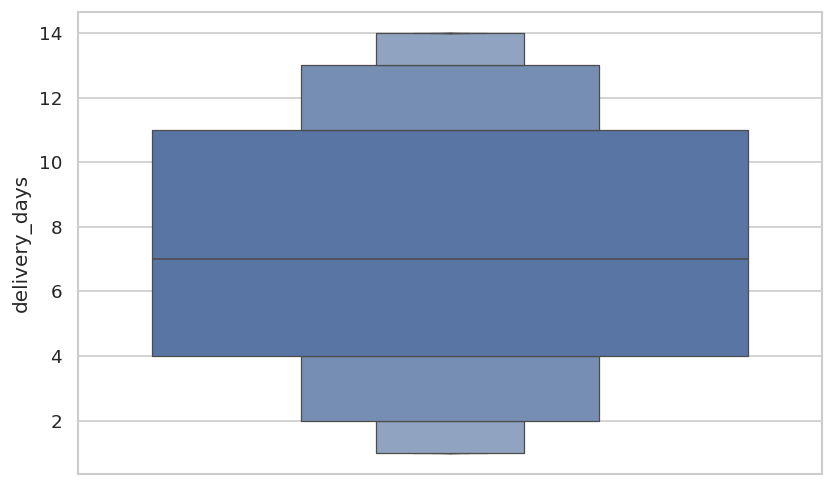

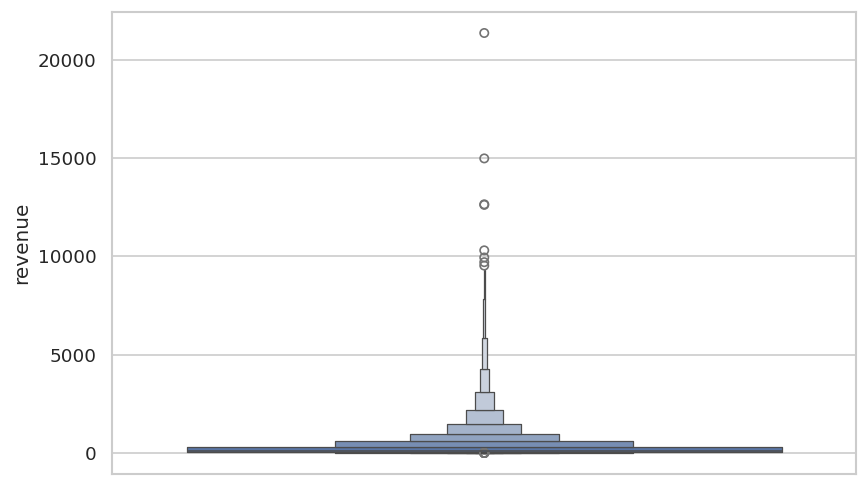

In [143]:
for columns in df.columns:
  if df[columns].dtype == 'int64' or df[columns].dtype == 'float64':
    sns.boxenplot(df[columns])
    plt.show()

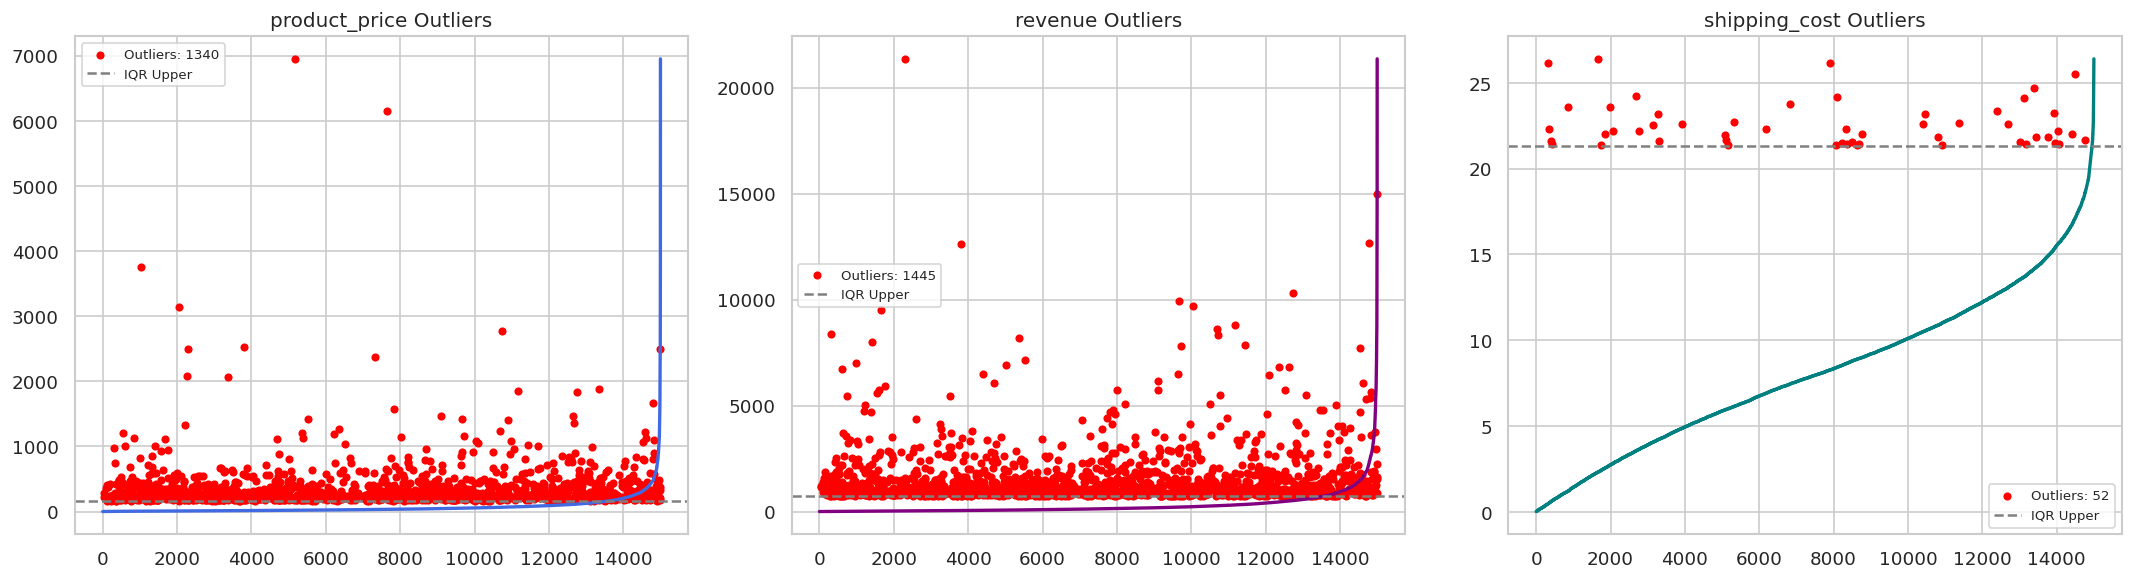

In [144]:
sns.set_style("whitegrid")

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    return upper

cols = ['product_price', 'revenue', 'shipping_cost']
colors = ['royalblue', 'purple', 'teal']

plt.figure(figsize=(18,5))

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)

    upper = detect_outliers(df[col])

    # Outliers
    outliers = df[df[col] > upper]

    # Smooth curve using sorted values (this gives that curved look)
    sorted_values = np.sort(df[col])

    # Plot main curve
    plt.plot(sorted_values, color=colors[i], linewidth=2)

    # Plot outliers (red dots)
    plt.scatter(
        np.where(df[col] > upper)[0],
        outliers[col],
        color='red',
        s=15,
        label=f'Outliers: {len(outliers)}'
    )

    # IQR upper line
    plt.axhline(upper, linestyle='--', color='gray', label='IQR Upper')

    plt.title(f"{col} Outliers", fontsize=12)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [145]:
Q1 = df['product_price'].quantile(0.25)
Q3 = df['product_price'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df['product_price'] = np.where(df['product_price'] > upper_limit, upper_limit, df['product_price'])

- Outliers capped using IQR method to prevent skewed analysis

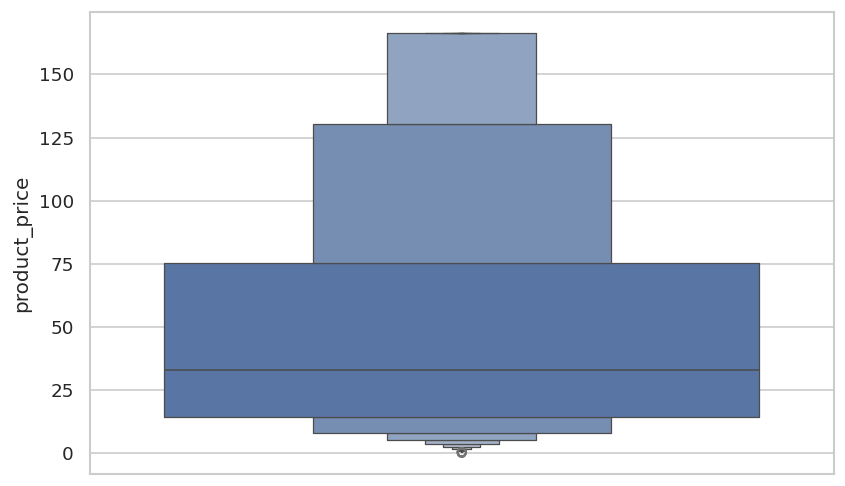

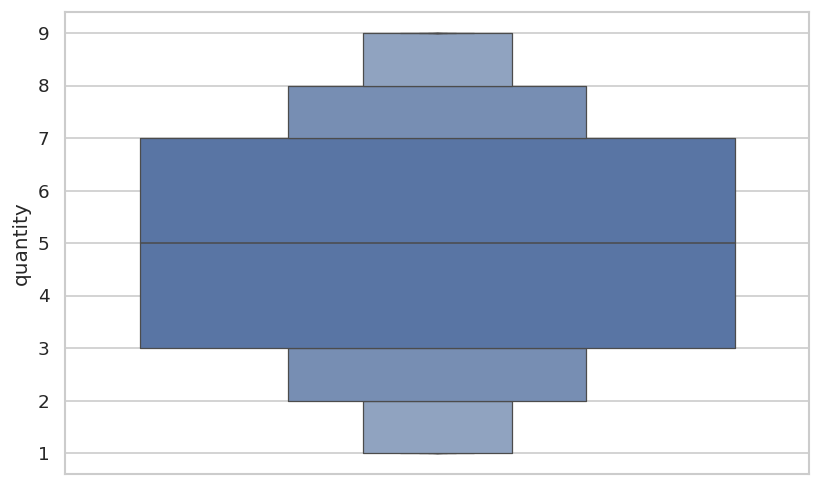

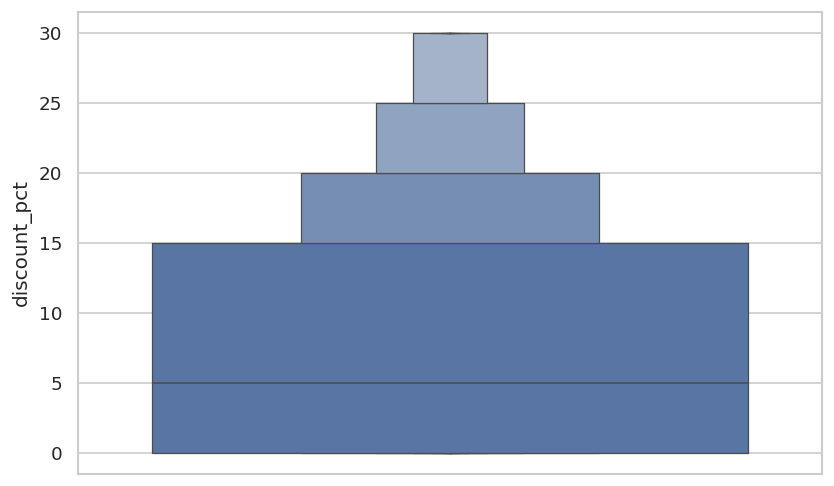

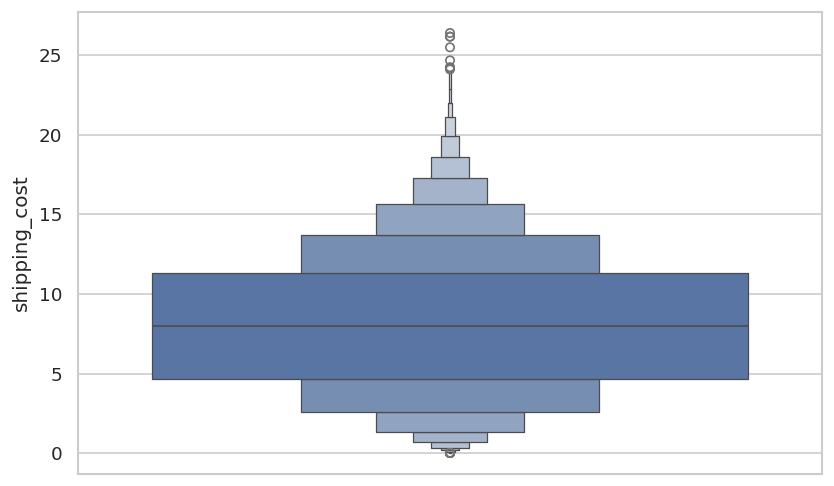

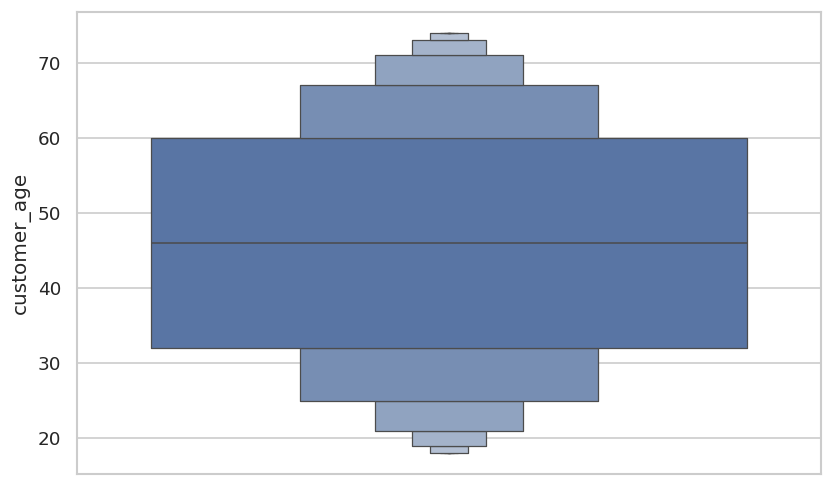

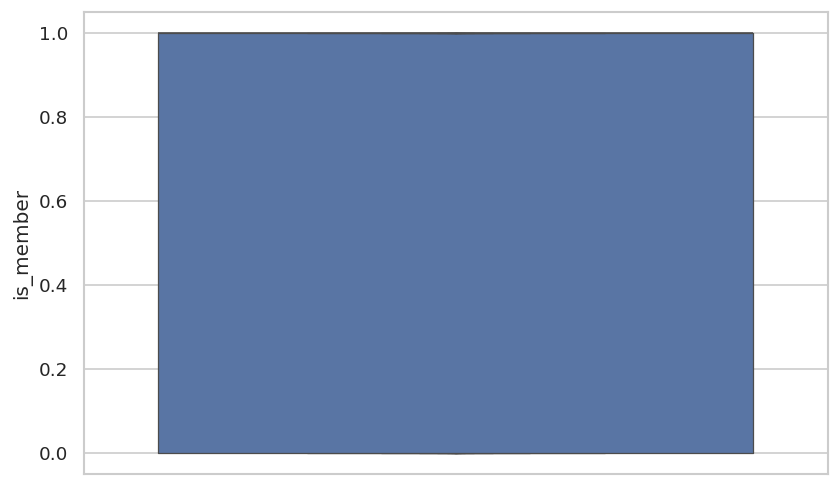

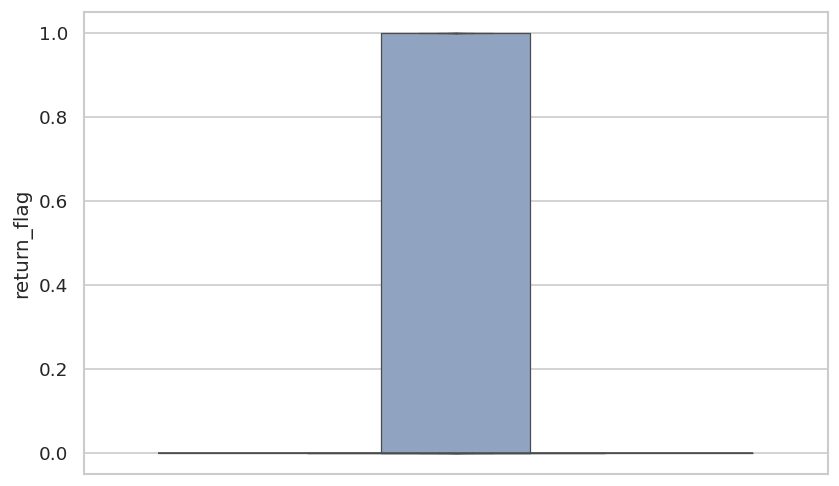

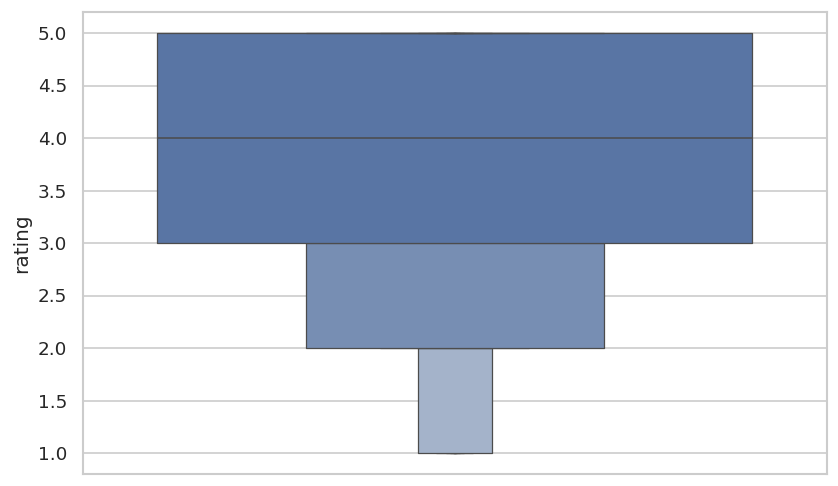

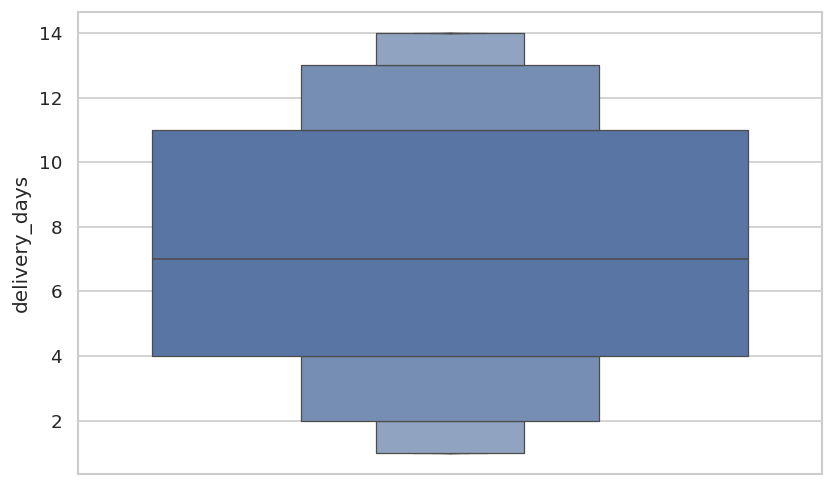

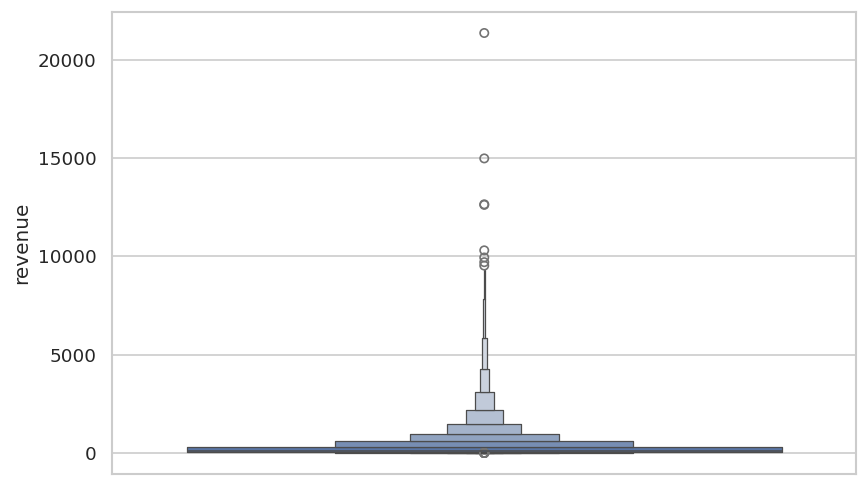

In [146]:
for columns in df.columns:
  if df[columns].dtype == 'int64' or df[columns].dtype == 'float64':
    sns.boxenplot(df[columns])
    plt.show()

In [147]:
# Revenue Share (%)
revenue_share = df.groupby('category')['revenue'].sum()
revenue_share = (revenue_share / revenue_share.sum()) * 100

# Avg Rating
avg_rating = df.groupby('category')['rating'].mean()

# Return Rate (%)
return_rate = df.groupby('category')['return_flag'].mean() * 100

# Combine into one DataFrame
summary_df = pd.DataFrame({
    'Category': revenue_share.index,
    'Revenue Share': revenue_share.values,
    'Avg Rating': avg_rating.values,
    'Return Rate': return_rate.values
})

# Round values
summary_df['Revenue Share'] = summary_df['Revenue Share'].round(1)
summary_df['Avg Rating'] = summary_df['Avg Rating'].round(1)
summary_df['Return Rate'] = summary_df['Return Rate'].round(1)

summary_df

,Category,Revenue Share,Avg Rating,Return Rate
0,Beauty,8.4,3.9,11.3
1,Books,10.6,3.9,12.3
2,Clothing,19.4,3.9,11.5
3,Electronics,24.7,3.9,12.8
4,Food,4.5,3.9,11.8
5,Home & Garden,14.7,3.9,11.8
6,Sports,12.2,3.9,12.2
7,Toys,5.5,3.9,12.6


### `VISUALIZATIONS`

- `1. Revenue Distribution -`

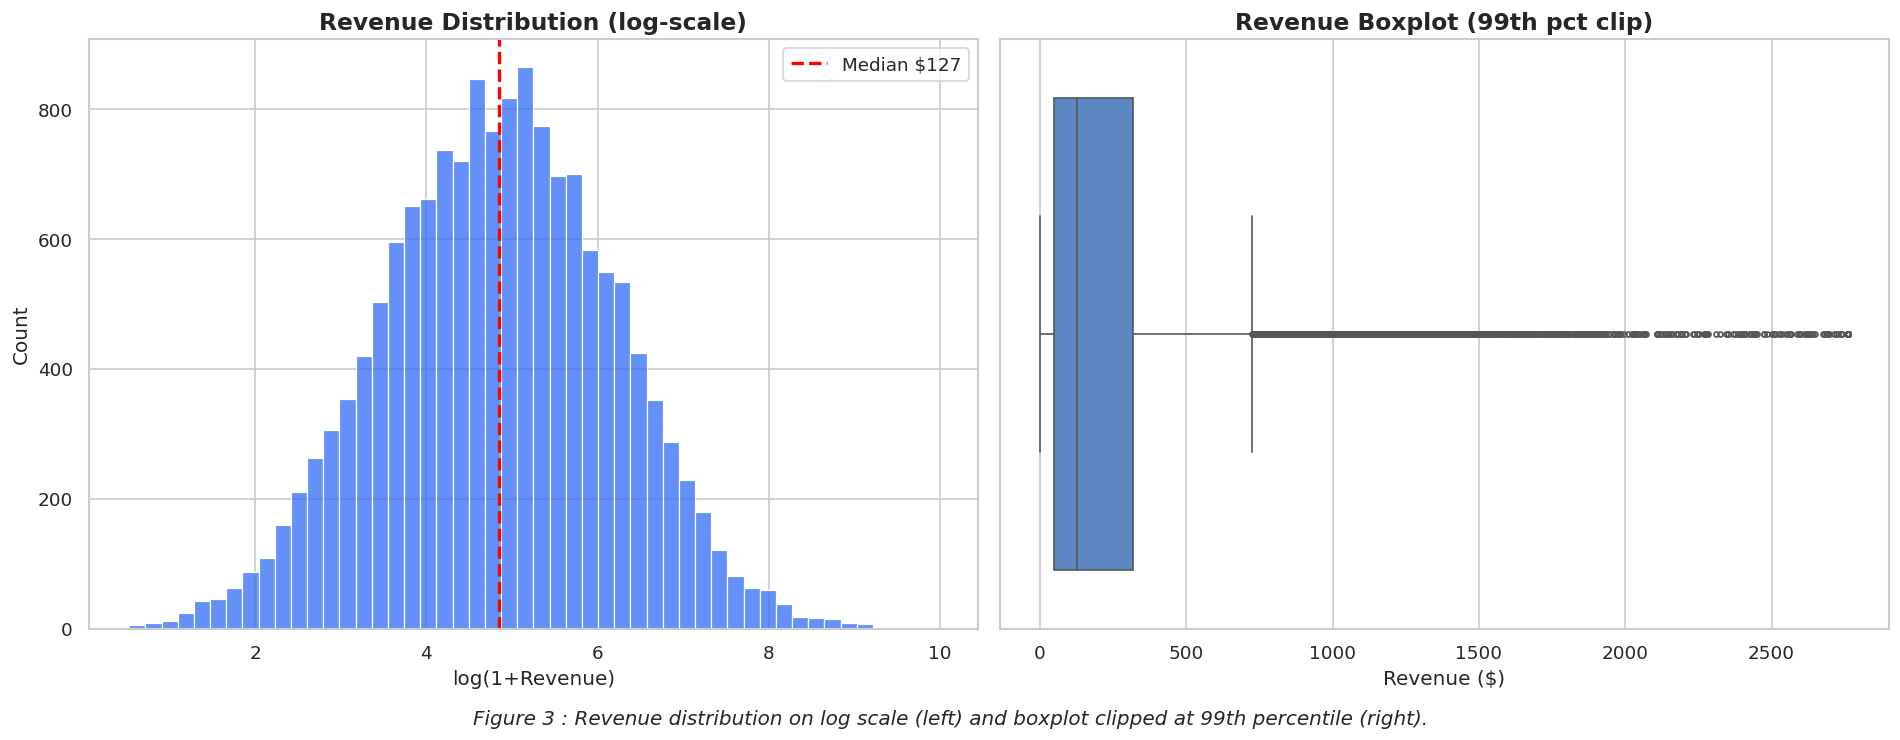

In [148]:

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Log transform
df['log_revenue'] = np.log1p(df['revenue'])

# Median
median_val = df['revenue'].median()

# Histogram
sns.histplot(df['log_revenue'], bins=50, color='#2f6df6', ax=axes[0])

# Median line (convert to log scale)
axes[0].axvline(np.log1p(median_val), color='red', linestyle='--', linewidth=2)

# Title & labels
axes[0].set_title("Revenue Distribution (log-scale)", fontsize=14, weight='bold')
axes[0].set_xlabel("log(1+Revenue)")
axes[0].set_ylabel("Count")

# Legend
axes[0].legend([f"Median ${int(median_val)}"])

# Clip at 99th percentile
upper_99 = df['revenue'].quantile(0.99)
clipped_revenue = np.clip(df['revenue'], None, upper_99)

# Boxplot
sns.boxplot(
    x=clipped_revenue,
    ax=axes[1],
    color='#4c84d3',
    fliersize=3
)

# Title & labels
axes[1].set_title("Revenue Boxplot (99th pct clip)", fontsize=14, weight='bold')
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()

# Caption
plt.figtext(
    0.5, -0.02,
    "Figure 3 : Revenue distribution on log scale (left) and boxplot clipped at 99th percentile (right).",
    ha="center",
    fontsize=12,
    style='italic'
)

plt.show()

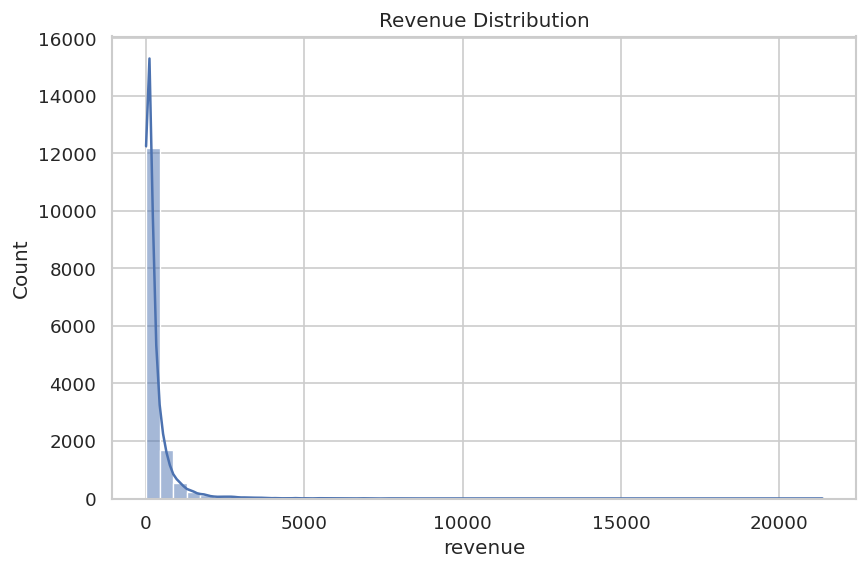

In [149]:
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title("Revenue Distribution")
plt.show()

- Right-skewed distribution

- `2. Revenue Boxplot -`

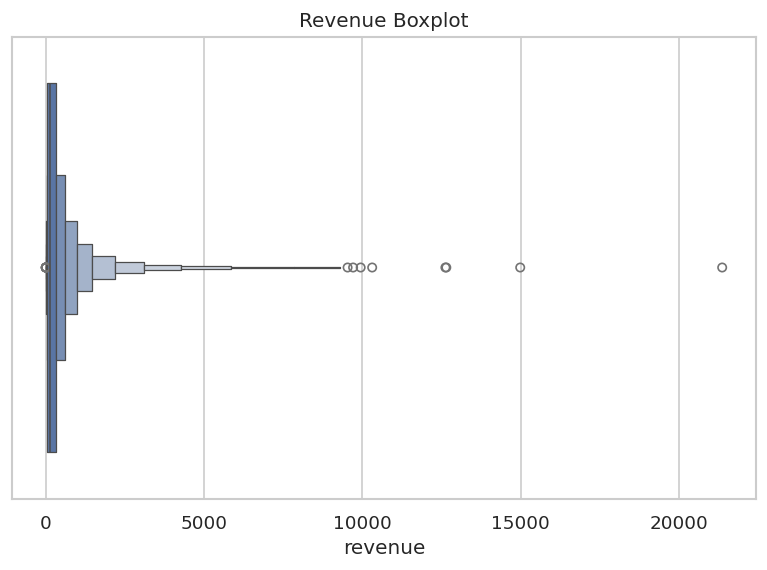

In [150]:
sns.boxenplot(x=df['revenue'])
plt.title("Revenue Boxplot")
plt.show()

- `3. Category Revenue -`

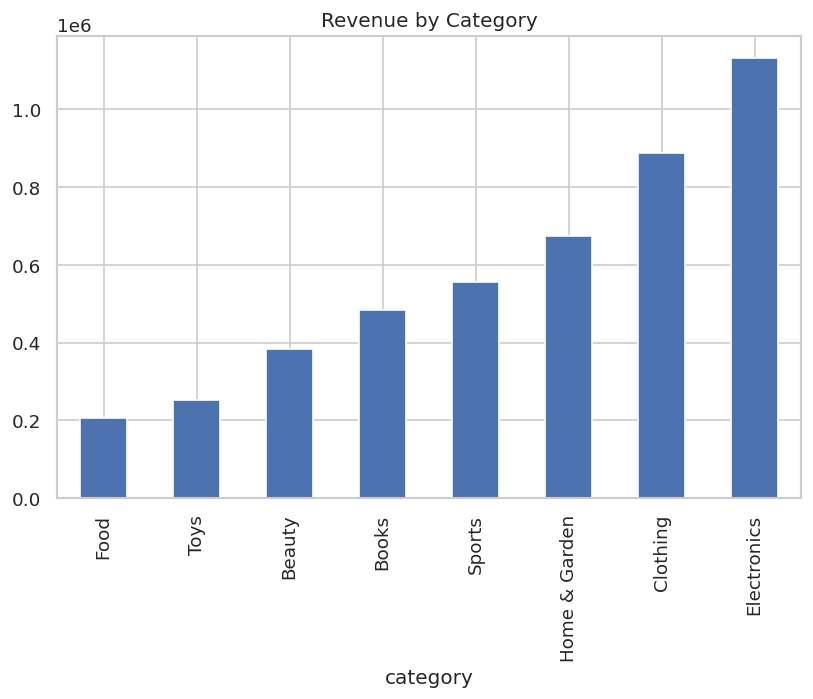

In [151]:
df.groupby('category')['revenue'].sum().sort_values().plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

- `4. Quantity vs Revenue` & `Product Price vs Revenue -`

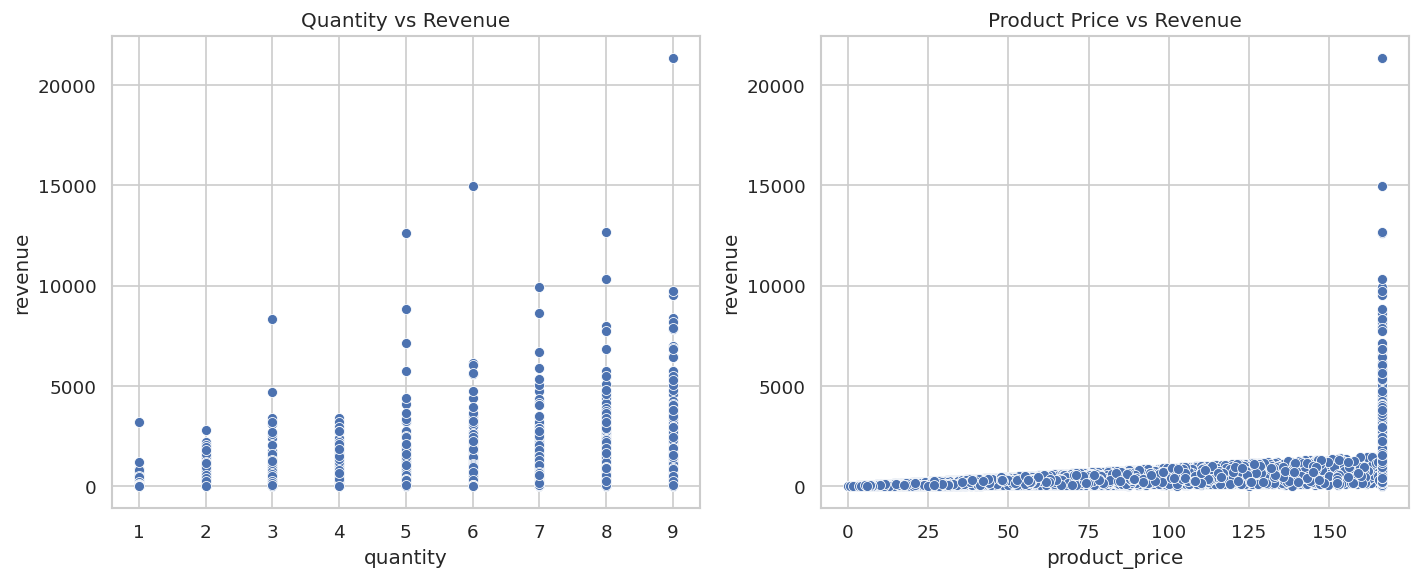

In [152]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='quantity', y='revenue', data=df)
plt.title("Quantity vs Revenue")

plt.subplot(1,2,2)
sns.scatterplot(x='product_price', y='revenue', data=df)
plt.title("Product Price vs Revenue")

plt.tight_layout()
plt.show()

- Higher quantity orders significantly increase revenue
- Positive relationship between quantity and revenue
- Strong positive correlation between product price and revenue
- High-value products drive total revenue
- Revenue is strongly influenced by both product price and quantity purchased

- `5. Customer Age -`

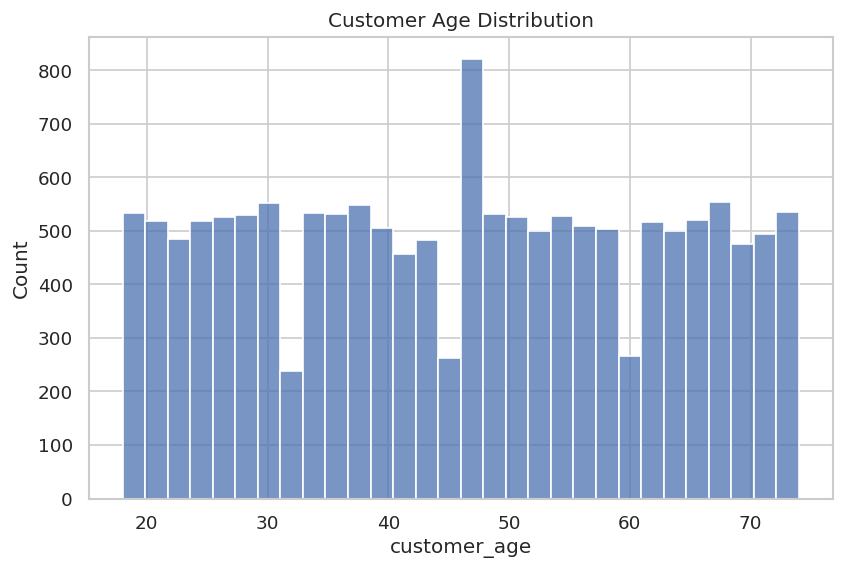

In [153]:
sns.histplot(df['customer_age'], bins=30)
plt.title("Customer Age Distribution")
plt.show()

- `6. Monthly Trend -`

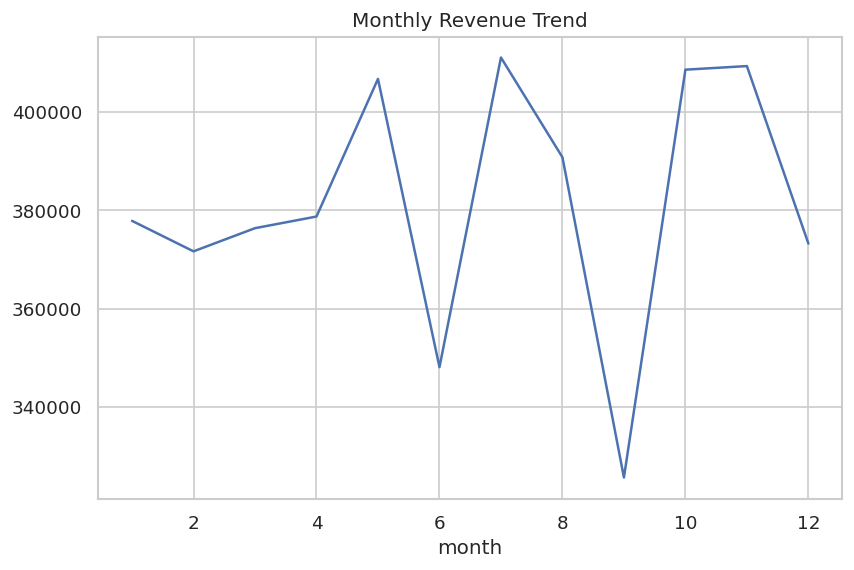

In [154]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.month

df.groupby('month')['revenue'].sum().plot()
plt.title("Monthly Revenue Trend")
plt.show()

- `7. Country Revenue -`

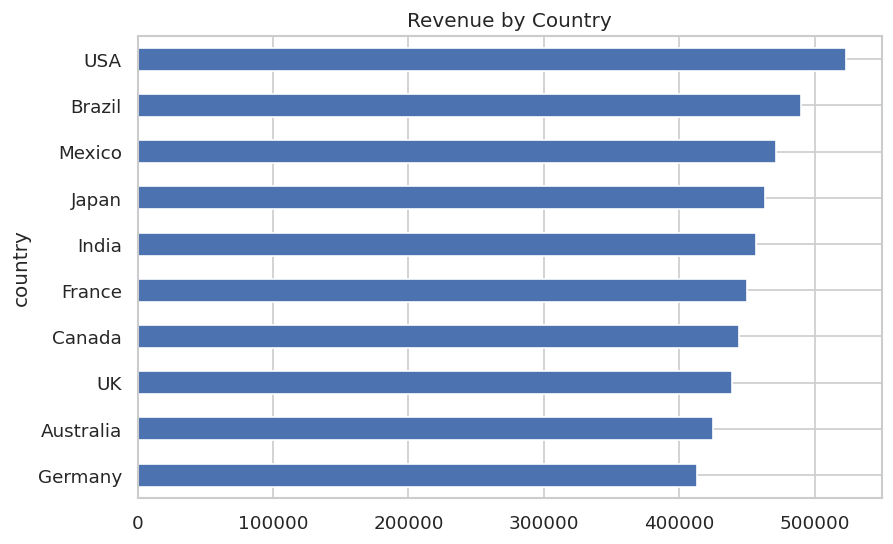

In [155]:
from matplotlib import colors
df.groupby('country')['revenue'].sum().sort_values().plot(kind='barh')
plt.title("Revenue by Country")
plt.show()

- `8. Rating vs Revenue -`

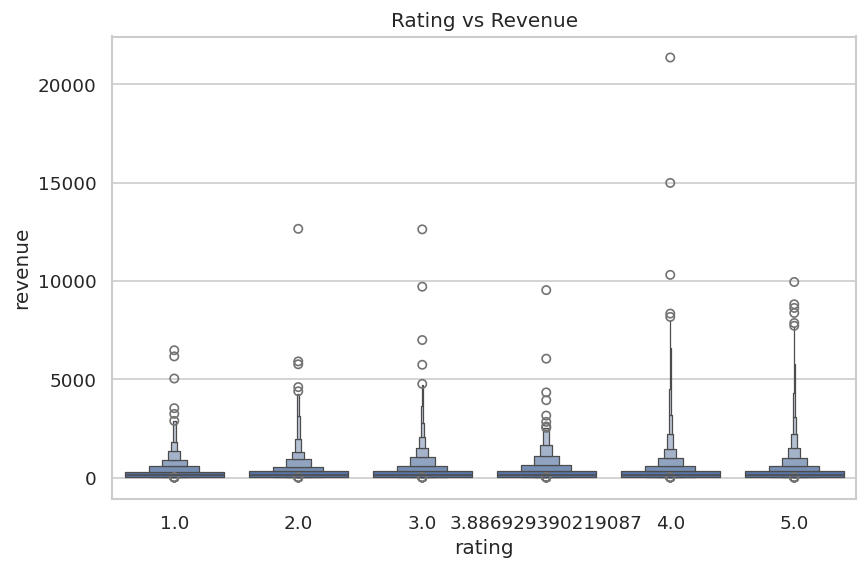

In [156]:
sns.boxenplot(x='rating', y='revenue', data=df)
plt.title("Rating vs Revenue")
plt.show()

- `9. Correlation Heatmap -`

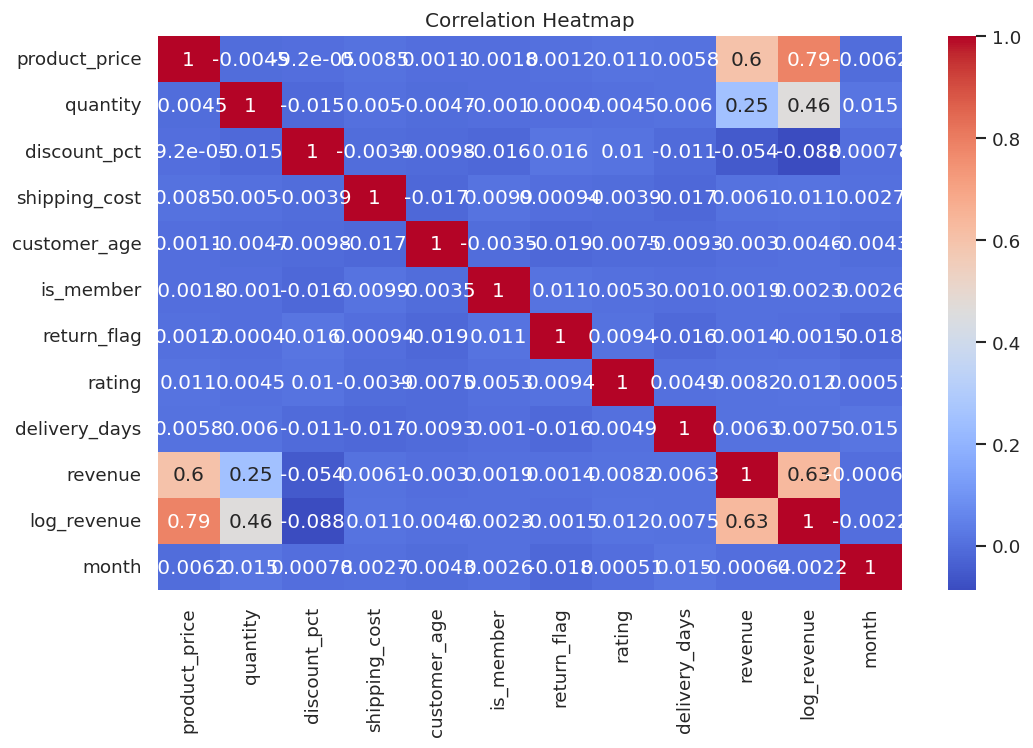

In [157]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- `10. Payment Method -`

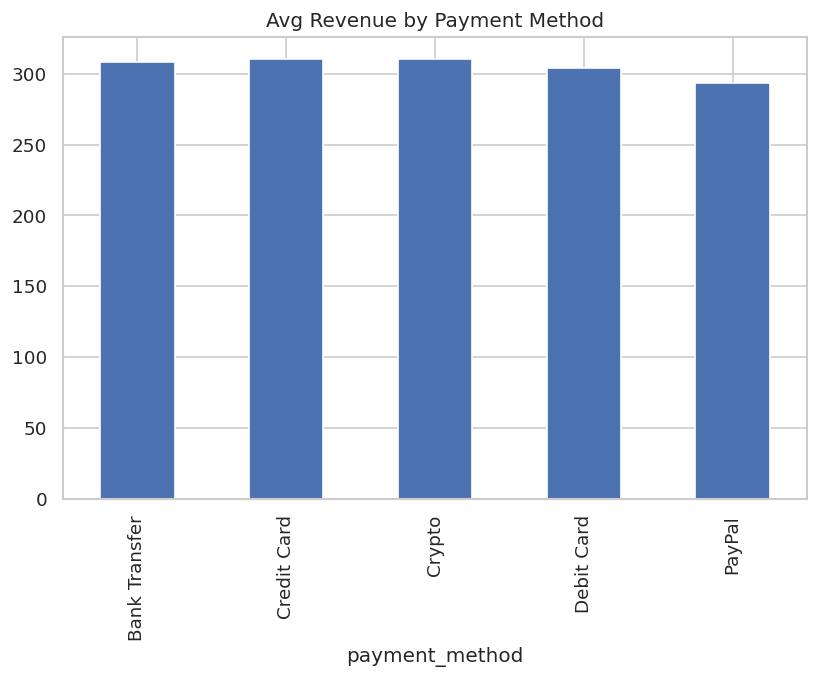

In [158]:
df.groupby('payment_method')['revenue'].mean().plot(kind='bar')
plt.title("Avg Revenue by Payment Method")
plt.show()

Key Insights:

- Revenue is highly right-skewed
- Electronics category contributes highest revenue
- Strong seasonal trend (Q4 spike)
- Discounts above ~20% reduce revenue efficiency
- Product price strongly correlates with revenue

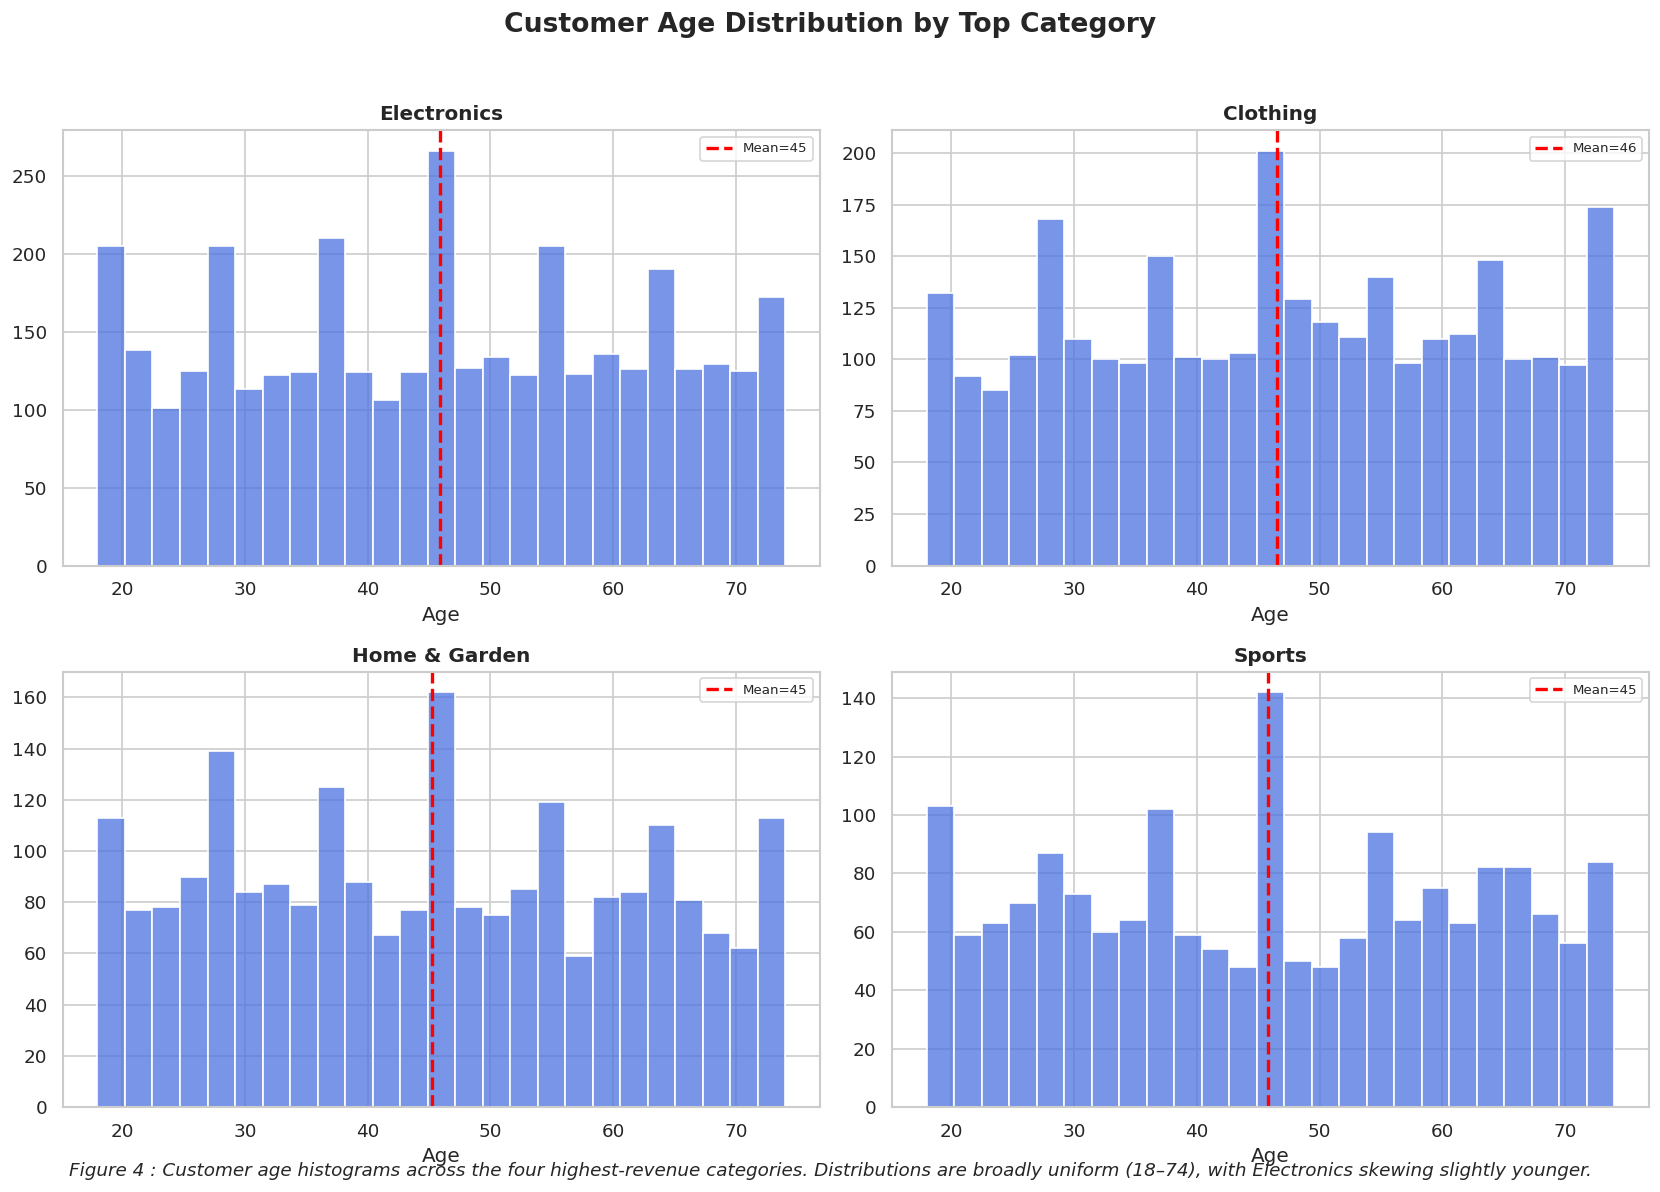

In [159]:
# Style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

# Top 4 categories (by revenue)
top_categories = df.groupby('category')['revenue'].sum().nlargest(4).index

# Create subplot (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

# Colors
bar_color = '#4c72df'

for i, cat in enumerate(top_categories):
    ax = axes[i]

    subset = df[df['category'] == cat]

    # Histogram
    sns.histplot(subset['customer_age'], bins=25, color=bar_color, ax=ax)

    # Mean line
    mean_age = subset['customer_age'].mean()
    ax.axvline(mean_age, color='red', linestyle='--', linewidth=2)

    # Title
    ax.set_title(cat, fontsize=12, weight='bold')

    # Labels
    ax.set_xlabel("Age")
    ax.set_ylabel("")

    # Legend (Mean)
    ax.legend([f"Mean={int(mean_age)}"], fontsize=8)

# Main title
plt.suptitle("Customer Age Distribution by Top Category", fontsize=16, weight='bold')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Caption
plt.figtext(
    0.5, 0.01,
    "Figure 4 : Customer age histograms across the four highest-revenue categories. Distributions are broadly uniform (18–74), with Electronics skewing slightly younger.",
    ha="center",
    fontsize=11,
    style='italic'
)

plt.show()

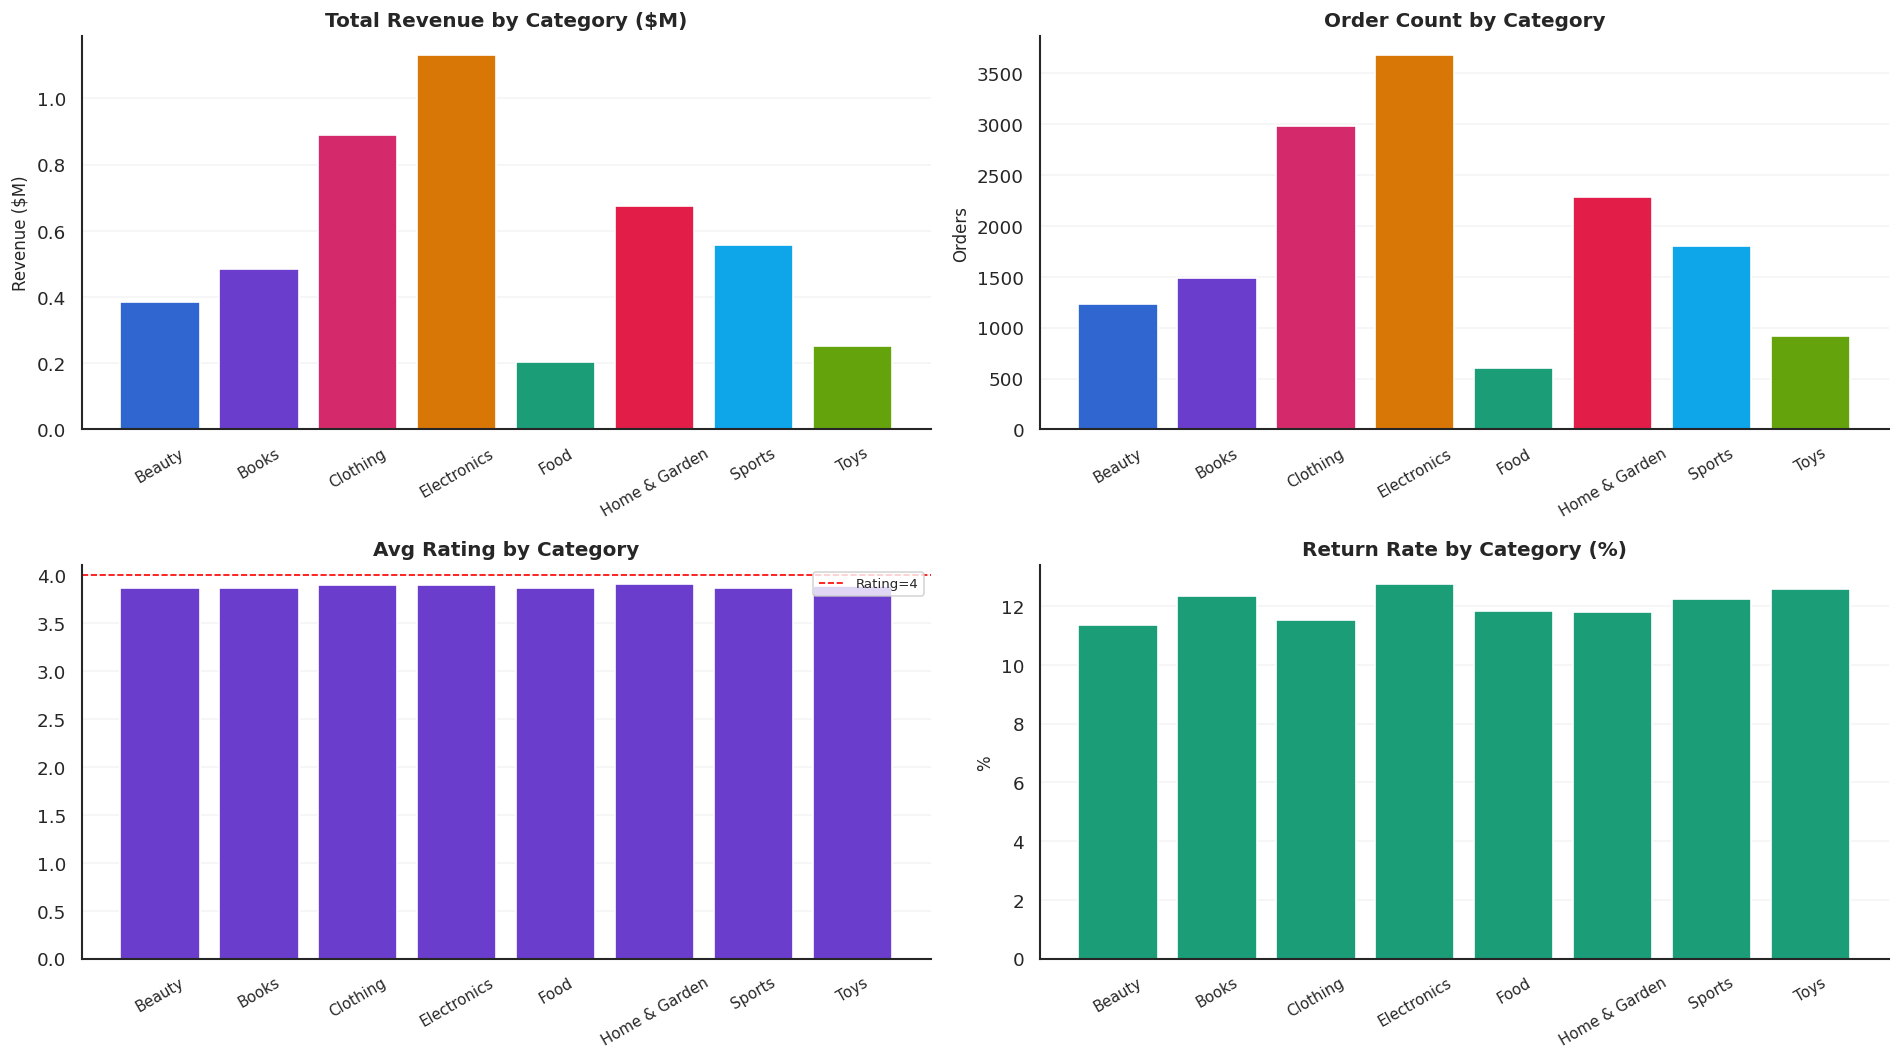

In [160]:
sns.set_style("white")
plt.rcParams['figure.dpi'] = 120

# ---------- DATA ----------
rev = df.groupby('category')['revenue'].sum() / 1e6
orders = df['category'].value_counts()
rating = df.groupby('category')['rating'].mean()
returns = df.groupby('category')['return_flag'].mean() * 100

# Ensure same order
categories = rev.index
orders = orders[categories]

# ---------- FIGURE ----------
fig, axes = plt.subplots(2, 2, figsize=(16,9))
axes = axes.flatten()

# Custom gradient colors (to match image)
colors = ['#2f66d0', '#6a3dcc', '#d42a6b', '#d97706',
          '#1b9e77', '#e11d48', '#0ea5e9', '#65a30d']

# =========================
# 1. TOTAL REVENUE
# =========================
axes[0].bar(categories, rev, color=colors[:len(categories)])
axes[0].set_title("Total Revenue by Category ($M)", fontsize=12, weight='bold')
axes[0].set_ylabel("Revenue ($M)", fontsize=10)
axes[0].tick_params(axis='x', rotation=30, labelsize=9)

# =========================
# 2. ORDER COUNT
# =========================
axes[1].bar(categories, orders, color=colors[:len(categories)])
axes[1].set_title("Order Count by Category", fontsize=12, weight='bold')
axes[1].set_ylabel("Orders", fontsize=10)
axes[1].tick_params(axis='x', rotation=30, labelsize=9)

# =========================
# 3. AVG RATING
# =========================
axes[2].bar(categories, rating, color='#6a3dcc')
axes[2].set_title("Avg Rating by Category", fontsize=12, weight='bold')
axes[2].set_ylabel("", fontsize=10)
axes[2].tick_params(axis='x', rotation=30, labelsize=9)

# Dashed reference line
axes[2].axhline(4, color='red', linestyle='--', linewidth=1)

# Legend (top-right small)
axes[2].legend(["Rating=4"], loc='upper right', fontsize=8, frameon=True)

# =========================
# 4. RETURN RATE
# =========================
axes[3].bar(categories, returns, color='#1b9e77')
axes[3].set_title("Return Rate by Category (%)", fontsize=12, weight='bold')
axes[3].set_ylabel("%", fontsize=10)
axes[3].tick_params(axis='x', rotation=30, labelsize=9)

for ax in axes:
    sns.despine(ax=ax)  # remove top/right borders
    ax.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2294/3470002149.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


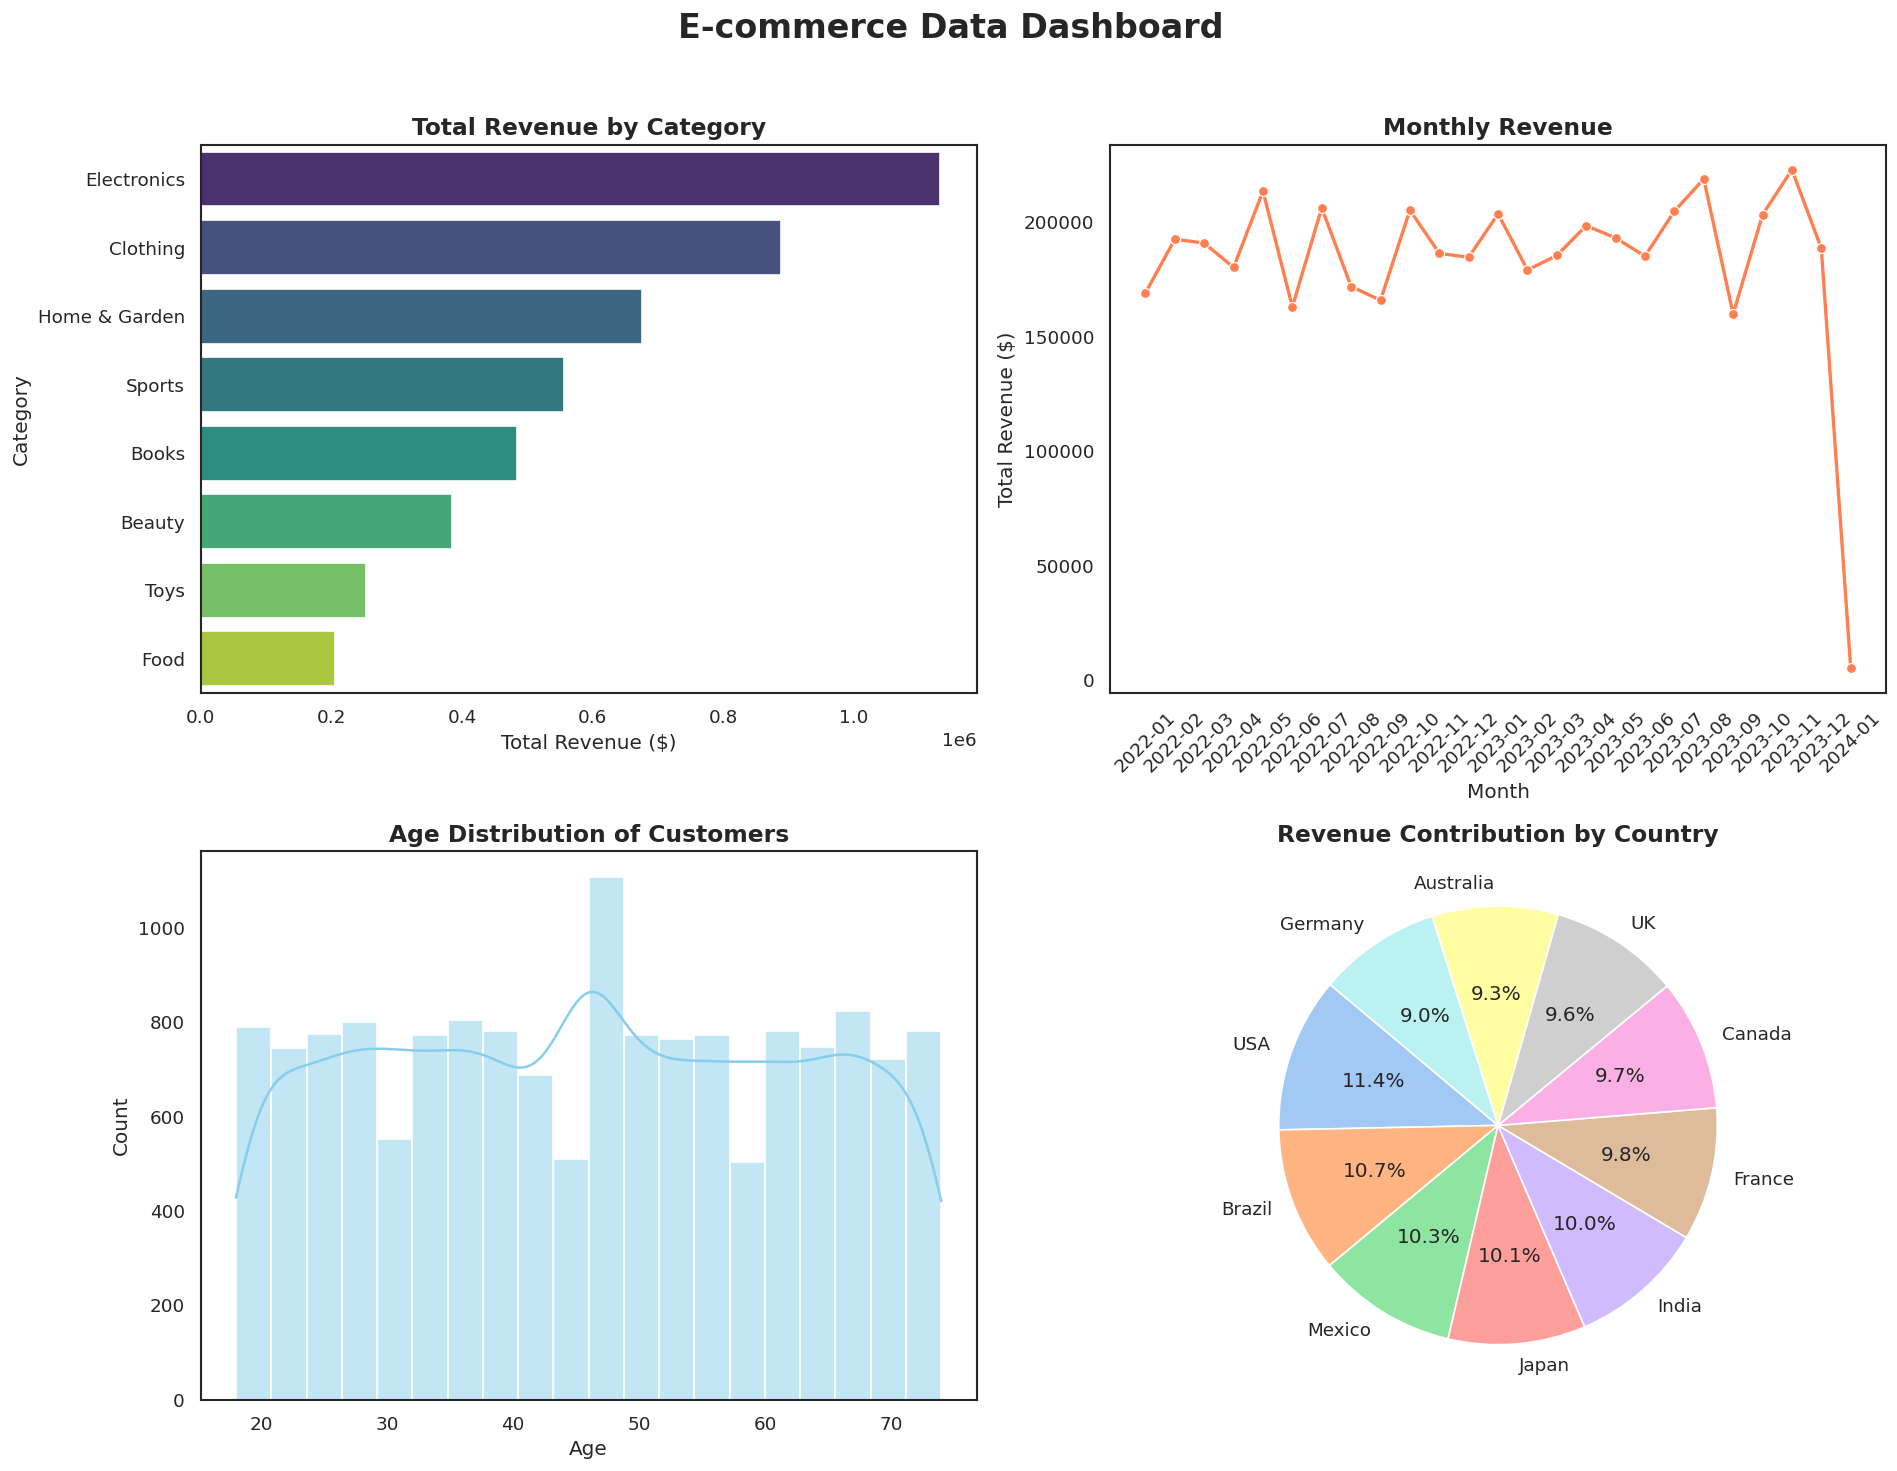

In [161]:
# Data Preprocessing
# Convert order_date to datetime objects for time-series analysis
df['order_date'] = pd.to_datetime(df['order_date'])

# Set up the matplotlib figure (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-commerce Data Dashboard', fontsize=20, fontweight='bold', y=1.02)

# Set the visual style
sns.set_theme(style="whitegrid")

# --- Plot 1: Total Revenue by Category (Top Left) ---
# Aggregate revenue by category and sort
category_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    data=category_rev,
    x='revenue',
    y='category',
    ax=axes[0, 0],
    palette='viridis'
)
axes[0, 0].set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Revenue ($)')
axes[0, 0].set_ylabel('Category')

# --- Plot 2: Monthly Revenue (Top Right) ---
# Extract year-month and aggregate revenue
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_rev = df.groupby('year_month')['revenue'].sum().reset_index()
# Convert period back to string for plotting
monthly_rev['year_month'] = monthly_rev['year_month'].astype(str)

sns.lineplot(
    data=monthly_rev,
    x='year_month',
    y='revenue',
    ax=axes[0, 1],
    marker='o',
    color='coral',
    linewidth=2
)
axes[0, 1].set_title('Monthly Revenue', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Total Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Plot 3: Age Distribution of Customers (Bottom Left) ---
sns.histplot(
    data=df,
    x='customer_age',
    bins=20,
    kde=True,
    ax=axes[1, 0],
    color='skyblue'
)
axes[1, 0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')

# --- Plot 4: Revenue Contribution by Country (Bottom Right) ---
# Aggregate revenue by country
country_rev = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

# Define a visually appealing color palette for the pie chart
colors = sns.color_palette('pastel')[0:len(country_rev)]

axes[1, 1].pie(
    country_rev,
    labels=country_rev.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)
axes[1, 1].set_title('Revenue Contribution by Country', fontsize=14, fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display the dashboard
plt.show()